# **Section 0: Environment Setup**

In [1]:
!pip install -q pytorch-lightning wfdb wandb seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.7 MB/s eta 0:00:00


# **MediScanX: End-to-End ECG Diagnostic Pipeline**

It imports the libraries required for the refactored ECG training workflow.

In [2]:
from __future__ import annotations

import ast
import os
from dataclasses import dataclass, field
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import seaborn as sns
import torch
import torch.nn.functional as F
import wandb
import wfdb
from kaggle_secrets import UserSecretsClient
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import WandbLogger
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from torch import Tensor, nn
from torch.utils.data import DataLoader, Dataset
from torchmetrics.classification import MultilabelF1Score

# **Section 1: Training Configuration**

This block defines the centralized ECG training configuration with static typing and hardware-aware defaults.

In [4]:
@dataclass
class ECGTrainingConfig:
    """Centralized configuration for the ECG training pipeline."""

    seed: int = 42
    batch_size: int = 64
    max_epochs: int = 30
    learning_rate: float = 1e-3
    sample_rate: int = 100
    seq_length: int = 500
    full_signal_length: int = 1000
    num_leads: int = 12
    num_workers: int = 2
    val_size: float = 0.1
    random_state: int = 42
    architecture: str = "Custom-1D-CNN-BiLSTM"
    project_name: str = "MediScanX-ECG-Scratch"
    run_name: str = "CNN-BiLSTM-OOP-Refactor"
    data_dir: str = (
        "/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/"
        "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/"
    )
    checkpoint_dir: str = "models"
    target_classes: list[str] = field(
        default_factory=lambda: ["NORM", "MI", "STTC", "CD", "HYP"]
    )
    device: torch.device = field(
        default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu")
    )


cfg = ECGTrainingConfig()
pl.seed_everything(cfg.seed)
print(f"Executing MediScanX ECG training on: {cfg.device}")

Seed set to 42


Executing MediScanX ECG training on: cuda


# Section 1.1: Experiment Telemetry Module

This block encapsulates Weights & Biases authentication and session cleanup inside a reusable class.

In [5]:
class ExperimentTracker:
    """Handles Weights & Biases authentication and logger construction."""

    @staticmethod
    def initialize(cfg: ECGTrainingConfig) -> WandbLogger:
        """Authenticate with W&B and return a Lightning logger."""

        try:
            user_secrets = UserSecretsClient()
            wandb_key = user_secrets.get_secret("wandb_api")
            wandb.login(key=wandb_key)
            print("Logged into W&B successfully.")
        except Exception as exc:
            print(f"Could not log into W&B. Error: {exc}")

        return WandbLogger(project=cfg.project_name, name=cfg.run_name)

    @staticmethod
    def close() -> None:
        """Safely close the active W&B run."""

        wandb.finish()

# **Section 2: Metadata Processing**

This block maps PTB-XL SCP codes into the five target ECG superclasses and returns a clean dataframe.

In [7]:
class PTBXLMetadataProcessor:
    """Loads PTB-XL metadata and maps SCP codes into ECG superclasses."""

    @staticmethod
    def load_and_process(cfg: ECGTrainingConfig) -> tuple[pd.DataFrame, list[str]]:
        """Create a label dataframe containing the five target ECG superclasses."""

        database_path = os.path.join(cfg.data_dir, "ptbxl_database.csv")
        mapping_path = os.path.join(cfg.data_dir, "scp_statements.csv")

        labels_df = pd.read_csv(database_path, index_col="ecg_id")
        labels_df["scp_codes"] = labels_df["scp_codes"].apply(ast.literal_eval)

        mapping_df = pd.read_csv(mapping_path, index_col=0)
        mapping_df = mapping_df[mapping_df["diagnostic"] == 1]

        def aggregate_superclasses(code_map: dict[str, float]) -> list[str]:
            diagnoses: list[str] = []
            for code in code_map.keys():
                if code in mapping_df.index:
                    diagnoses.append(str(mapping_df.loc[code, "diagnostic_class"]))
            return sorted(set(diagnoses))

        labels_df["diagnostic_superclass"] = labels_df["scp_codes"].apply(aggregate_superclasses)

        mlb = MultiLabelBinarizer()
        encoded = pd.DataFrame(
            mlb.fit_transform(labels_df["diagnostic_superclass"]),
            columns=mlb.classes_,
            index=labels_df.index,
        )

        final_df = encoded[cfg.target_classes].copy()
        final_df["filename"] = labels_df["filename_lr"]
        return final_df, cfg.target_classes

# **Section 3: Dataset Implementation**

This block defines the dataset class that loads, normalizes, chunks, and tensorizes ECG signals.

In [8]:
class PTBXLDataset(Dataset[tuple[Tensor, Tensor]]):
    """Dataset for PTB-XL ECG records using a two-chunk representation."""

    def __init__(self, dataframe: pd.DataFrame, root_dir: str, cfg: ECGTrainingConfig) -> None:
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.cfg = cfg
        self.indices = self.dataframe.index.tolist()

    def __len__(self) -> int:
        """Return the dataset size."""

        return len(self.indices)

    def __getitem__(self, idx: int) -> tuple[Tensor, Tensor]:
        """Load and normalize a single ECG sample."""

        ecg_id = self.indices[idx]
        filename = str(self.dataframe.loc[ecg_id, "filename"])
        labels = self.dataframe.loc[ecg_id, self.cfg.target_classes].values.astype(np.float32)
        file_path = os.path.join(self.root_dir, filename)

        try:
            signal, _ = wfdb.rdsamp(file_path)
        except Exception as exc:
            print(f"Error loading {file_path}: {exc}")
            empty_signal = torch.zeros(2, self.cfg.num_leads, self.cfg.seq_length)
            empty_labels = torch.zeros(len(self.cfg.target_classes))
            return empty_signal, empty_labels

        normalized = (signal - np.mean(signal, axis=0)) / (np.std(signal, axis=0) + 1e-6)
        first_chunk = torch.tensor(
            normalized[: self.cfg.seq_length, :].T, dtype=torch.float32
        )
        second_chunk = torch.tensor(
            normalized[self.cfg.seq_length : self.cfg.full_signal_length, :].T,
            dtype=torch.float32,
        )
        label_tensor = torch.tensor(labels, dtype=torch.float32)
        return torch.stack([first_chunk, second_chunk]), label_tensor

# Section 3.1: Data Routing Module

This block creates the ECG data module responsible for train/validation splits and dataloaders.

In [10]:
class ECGDataModule:
    """Factory class for metadata routing, dataset creation, and dataloaders."""

    def __init__(self, cfg: ECGTrainingConfig) -> None:
        self.cfg = cfg
        self.class_names: list[str] = []

    def setup(self) -> tuple[DataLoader[tuple[Tensor, Tensor]], DataLoader[tuple[Tensor, Tensor]]]:
        """Create train and validation dataloaders."""

        labels_df, self.class_names = PTBXLMetadataProcessor.load_and_process(self.cfg)
        train_df, val_df = train_test_split(
            labels_df,
            test_size=self.cfg.val_size,
            random_state=self.cfg.random_state,
        )

        train_dataset = PTBXLDataset(train_df, self.cfg.data_dir, self.cfg)
        val_dataset = PTBXLDataset(val_df, self.cfg.data_dir, self.cfg)

        train_loader = DataLoader(
            train_dataset,
            batch_size=self.cfg.batch_size,
            shuffle=True,
            num_workers=self.cfg.num_workers,
            pin_memory=self.cfg.device.type == "cuda",
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=self.cfg.batch_size,
            shuffle=False,
            num_workers=self.cfg.num_workers,
            pin_memory=self.cfg.device.type == "cuda",
        )
        print(
            f"Data routing complete. Train: {len(train_dataset)} | Val: {len(val_dataset)}"
        )
        return train_loader, val_loader

# **Section 4: Model Architecture (MediScanXECGClassifier)**

This block defines the shared 1D CNN + BiLSTM model that is reused by both training and inference.

In [11]:
class MediScanXECGClassifier(pl.LightningModule):
    """1D CNN + BiLSTM classifier used as the shared ECG architecture."""

    def __init__(self, cfg: ECGTrainingConfig) -> None:
        super().__init__()
        self.save_hyperparameters(ignore=["cfg"])
        self.cfg = cfg

        self.conv1 = nn.Conv1d(cfg.num_leads, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(2)

        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
        )
        self.fc1 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(128, len(cfg.target_classes))

        self.criterion = nn.BCEWithLogitsLoss()
        self.f1_score = MultilabelF1Score(
            num_labels=len(cfg.target_classes),
            average="macro",
        )

    def extract_features(self, x: Tensor) -> Tensor:
        """Extract convolutional feature maps for classification or Grad-CAM."""

        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        return x

    def classify_features(self, features: Tensor) -> Tensor:
        """Classify feature maps into ECG pathology logits."""

        sequence_features = features.permute(0, 2, 1)
        sequence_features, _ = self.lstm(sequence_features)
        pooled = torch.mean(sequence_features, dim=1)
        hidden = F.relu(self.fc1(pooled))
        hidden = self.dropout(hidden)
        return self.fc2(hidden)

    def forward(self, x: Tensor) -> Tensor:
        """Run a forward pass on a batched chunked ECG tensor."""

        batch_size, chunks, channels, timesteps = x.shape
        merged = x.view(batch_size * chunks, channels, timesteps)
        features = self.extract_features(merged)
        logits = self.classify_features(features)
        logits = logits.view(batch_size, chunks, -1)
        return torch.mean(logits, dim=1)

    def training_step(self, batch: tuple[Tensor, Tensor], batch_idx: int) -> Tensor:
        """Perform one Lightning training step."""

        signals, labels = batch
        logits = self(signals)
        loss = self.criterion(logits, labels)
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch: tuple[Tensor, Tensor], batch_idx: int) -> Tensor:
        """Perform one Lightning validation step."""

        signals, labels = batch
        logits = self(signals)
        loss = self.criterion(logits, labels)
        self.f1_score(torch.sigmoid(logits), labels.int())
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_f1", self.f1_score, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self) -> torch.optim.Optimizer:
        """Configure the optimizer for Lightning."""

        return torch.optim.Adam(self.parameters(), lr=self.cfg.learning_rate)

# **Section 5: Evaluation Dashboard**

This block adds the confusion-matrix reporting utility for post-training validation review.

In [12]:
class ECGEvaluationDashboard:
    """Utility class for multilabel confusion-matrix reporting."""

    @staticmethod
    def plot(
        model: MediScanXECGClassifier,
        dataloader: DataLoader[tuple[Tensor, Tensor]],
        class_names: list[str],
        device: torch.device,
    ) -> None:
        """Generate a confusion-matrix figure using validation predictions."""

        model.to(device)
        model.eval()
        all_preds: list[np.ndarray] = []
        all_targets: list[np.ndarray] = []

        with torch.no_grad():
            for signals, labels in dataloader:
                signals = signals.to(device)
                logits = model(signals)
                preds = (torch.sigmoid(logits) > 0.5).int().cpu().numpy()
                all_preds.extend(preds)
                all_targets.extend(labels.int().cpu().numpy())

        preds_array = np.array(all_preds)
        targets_array = np.array(all_targets)
        matrices = multilabel_confusion_matrix(targets_array, preds_array)

        fig, axes = plt.subplots(1, len(class_names), figsize=(28, 6))
        fig.suptitle(
            "MediScanX 1D-CNN + Bi-LSTM: Clinical Evaluation Results (PTB-XL Dataset)",
            fontsize=24,
            fontweight="bold",
            y=1.05,
        )

        tick_labels = ["Negative", "Positive"]
        for axis, matrix, class_name in zip(axes, matrices, class_names):
            sns.heatmap(
                matrix,
                annot=True,
                fmt="d",
                cmap="Blues",
                ax=axis,
                cbar=False,
                annot_kws={"size": 18, "weight": "bold"},
                xticklabels=tick_labels,
                yticklabels=tick_labels,
            )
            axis.set_title(f"Class: {class_name}", fontsize=20, fontweight="bold", pad=15)
            axis.set_xlabel("Predicted by Model", fontsize=16, labelpad=10)
            axis.set_ylabel("Actual Condition", fontsize=16, labelpad=10)
            axis.tick_params(axis="both", which="major", labelsize=14)

        plt.tight_layout()
        plt.show()

# **Section 6: Pipeline Execution Engine**

This final block orchestrates the full ECG training workflow, including callbacks, training, checkpoint loading, and dashboard generation.

/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)
Seed set to 42
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb log

Logged into W&B successfully.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Data routing complete. Train: 19653 | Val: 2184
Starting ECG training pipeline...


wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


...

┏━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ conv1     │ Conv1d            │  3.9 K │ train │     0 │
│ 1  │ bn1       │ BatchNorm1d       │    128 │ train │     0 │
│ 2  │ pool1     │ MaxPool1d         │      0 │ train │     0 │
│ 3  │ conv2     │ Conv1d            │ 41.1 K │ train │     0 │
│ 4  │ bn2       │ BatchNorm1d       │    256 │ train │     0 │
│ 5  │ pool2     │ MaxPool1d         │      0 │ train │     0 │
│ 6  │ conv3     │ Conv1d            │ 98.6 K │ train │     0 │
│ 7  │ bn3       │ BatchNorm1d       │    512 │ train │     0 │
│ 8  │ pool3     │ MaxPool1d         │      0 │ train │     0 │
│ 9  │ lstm      │ LSTM              │  790 K │ train │     0 │
│ 10 │ fc1       │ Linear            │ 32.9 K │ train │     0 │
│ 11 │ dropout   │ Dropout           │      0 │ train │     0 │
│ 12 │ fc2       │ Linear            │    645 │ train │     0 │
│ 13 │ criterion │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 14 │ f1_score  │ MultilabelF1Score │      0 │ train │     0 │
└────┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 968 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 968 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 0.353
Metric val_loss improved by 0.031 >= min_delta = 0.0. New best score: 0.322
Metric val_loss improved by 0.023 >= min_delta = 0.0. New best score: 0.299
Metric val_loss improved by 0.003 >= min_delta = 0.0. New best score: 0.295
Metric val_loss improved by 0.011 >= min_delta = 0.0. New best score: 0.284
Metric val_loss improved by 0.008 >= min_delta = 0.0. New best score: 0.276
Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.275
Metric val_loss improved by 0.012 >= min_delta = 0.0. New best score: 0.264
Metric val_loss improved by 0.003 >= min_delta = 0.0. New best score: 0.261
Monitored metric val_loss did not improve in the last 5 records. Best score: 0.261. Signaling Trainer to stop.


Training stopped. Best model saved at: /kaggle/working/models/mediscanx-best-ecg-model-epoch=10-val_loss=0.261.ckpt


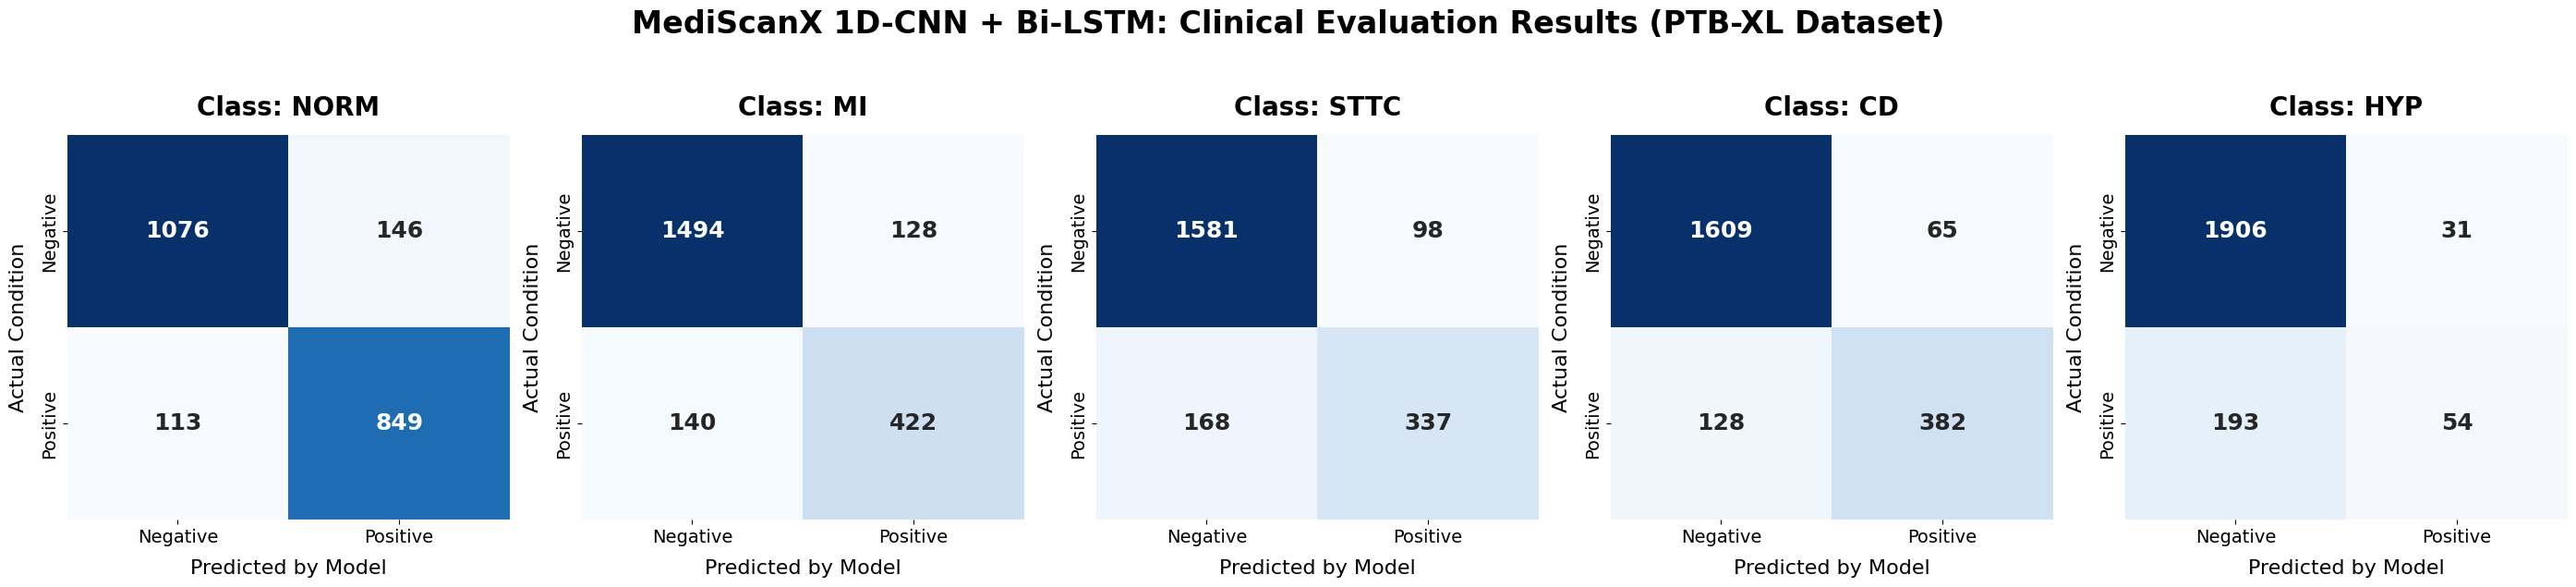

epoch,▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇████
train_loss,█▆▅▄▄▃▃▃▃▂▂▂▂▂▁▁
trainer/global_step,▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇████
val_f1,▁▅▆▆▇▆▇▇▇▇▇▇▇██▇
val_loss,█▆▄▄▃▂▂▃▂▁▁▁▁▂▂▄
epoch,15
train_loss,0.2116
trainer/global_step,4927
val_f1,0.69534
val_loss,0.29503


In [13]:
class ECGTrainingPipeline:
    """End-to-end orchestration layer for ECG model training and evaluation."""

    def __init__(self, cfg: ECGTrainingConfig) -> None:
        self.cfg = cfg

    def _build_callbacks(self) -> list[Any]:
        """Create the checkpointing and early-stopping callbacks."""

        checkpoint_callback = ModelCheckpoint(
            monitor="val_loss",
            dirpath=self.cfg.checkpoint_dir,
            filename="mediscanx-best-ecg-model-{epoch:02d}-{val_loss:.3f}",
            save_top_k=1,
            mode="min",
        )
        early_stop_callback = EarlyStopping(
            monitor="val_loss",
            min_delta=0.0,
            patience=5,
            verbose=True,
            mode="min",
        )
        return [checkpoint_callback, early_stop_callback]

    def run(self) -> None:
        """Execute the ECG training workflow."""

        torch.set_float32_matmul_precision("medium")
        pl.seed_everything(self.cfg.seed)

        logger = ExperimentTracker.initialize(self.cfg)
        data_module = ECGDataModule(self.cfg)
        train_loader, val_loader = data_module.setup()

        model = MediScanXECGClassifier(self.cfg)
        callbacks = self._build_callbacks()

        trainer = pl.Trainer(
            max_epochs=self.cfg.max_epochs,
            accelerator="gpu" if self.cfg.device.type == "cuda" else "cpu",
            devices=1,
            logger=logger,
            log_every_n_steps=10,
            callbacks=callbacks,
        )

        print("Starting ECG training pipeline...")
        trainer.fit(model, train_loader, val_loader)

        checkpoint_callback = callbacks[0]
        if isinstance(checkpoint_callback, ModelCheckpoint):
            print(f"Training stopped. Best model saved at: {checkpoint_callback.best_model_path}")
            best_model = MediScanXECGClassifier.load_from_checkpoint(
                checkpoint_callback.best_model_path,
                cfg=self.cfg,
            )
            ECGEvaluationDashboard.plot(
                model=best_model,
                dataloader=val_loader,
                class_names=data_module.class_names,
                device=self.cfg.device,
            )

        ExperimentTracker.close()


def main() -> None:
    """Entry point for the refactored ECG training script."""

    config = ECGTrainingConfig()
    pipeline = ECGTrainingPipeline(config)
    pipeline.run()


main()